In [1]:
import os

print("Current directory:")
print(os.getcwd())


Current directory:
/data/ceph/hdd/project/node_07/ml4rg_students/2026/project06/glm-functional-element-discovery/notebooks


In [3]:
import pandas as pd


In [5]:
# Load results
df = pd.read_csv(
    "../outputs/runs/evo2-baseline-v1/reconstruction/per_region.csv"
)
print(df.shape)
df.head()

(3112, 24)


,run_id,dataset_id,model_id,checkpoint_tag,region_id,record_id,species,source_row,annotation_file,start,...,evaluated_base_count,mean_true_base_probability,mean_cross_entropy_bits,median_cross_entropy_bits,std_cross_entropy_bits,q05_cross_entropy_bits,q25_cross_entropy_bits,q75_cross_entropy_bits,q95_cross_entropy_bits,accuracy
0,evo2-baseline-v1,ribosome,evo2_7b,NaN,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,0,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,0,...,1855.0,0.367583,1.671805,1.788503,0.802146,0.101537,1.327359,2.149348,2.789813,0.477628
1,evo2-baseline-v1,ribosome,evo2_7b,NaN,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,1,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,3340,...,154.0,0.313231,1.844265,1.891563,0.654031,0.275773,1.625303,2.213972,2.799616,0.389610
2,evo2-baseline-v1,ribosome,evo2_7b,NaN,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,2,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,4586,...,4880.0,0.322246,1.777245,1.771989,0.644095,0.598928,1.454883,2.109737,2.798452,0.428893
3,evo2-baseline-v1,ribosome,evo2_7b,NaN,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,4,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,9859,...,18.0,0.315537,1.789037,1.664990,0.647170,0.927830,1.352571,2.223506,2.725017,0.333333
4,evo2-baseline-v1,ribosome,evo2_7b,NaN,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,3,Mammalia-Artiodactyla-Addax nasomaculatus-GCA_...,9859,...,247.0,0.438615,1.458069,1.470791,0.932899,0.073145,0.950436,1.991019,2.903019,0.542510


In [6]:
summary = (
    df.groupby("feature_type")
      .agg(
          accuracy=("accuracy", "mean"),
          ce=("mean_cross_entropy_bits", "mean"),
          bases=("evaluated_base_count", "sum")
      )
      .sort_values("accuracy", ascending=False)
)

summary

,accuracy,ce,bases
feature_type,,,
18S_rRNA,0.479146,1.657441,18662.0
28S_rRNA,0.429677,1.771769,24174.0
Terminator,0.421622,1.685941,4298.0
5_8S_rRNA,0.386519,1.843716,771.0
Upstream,0.382211,1.938424,468.0
EnhancerRepeats,0.375429,1.882778,8000.0
CompositePromoter,0.357053,1.905145,6855.0
TTF1,0.355072,1.826123,1242.0
CTCF,0.350000,1.777337,100.0


In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

summary["accuracy"].plot(kind="bar")

plt.ylabel("Mean Reconstruction Accuracy")
plt.xlabel("Feature Type")
plt.title("Evo2 Reconstruction Accuracy by Feature Type")

plt.tight_layout()

plt.show()

<Figure size 1000x500 with 1 Axes>

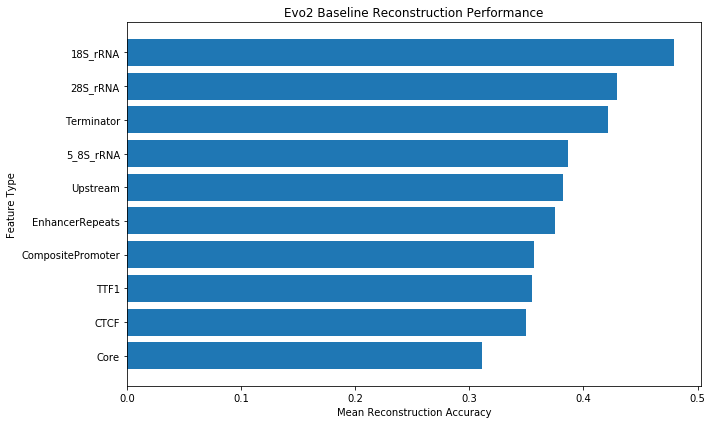

In [8]:
import matplotlib.pyplot as plt

plot_df = summary.sort_values("accuracy", ascending=True)

plt.figure(figsize=(10,6))

plt.barh(
    plot_df.index,
    plot_df["accuracy"]
)

plt.xlabel("Mean Reconstruction Accuracy")
plt.ylabel("Feature Type")
plt.title("Evo2 Baseline Reconstruction Performance")

plt.tight_layout()

plt.show()

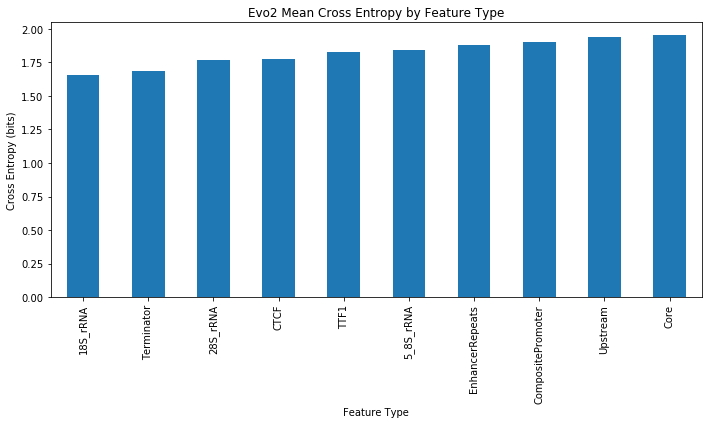

In [10]:
ce = (
    df.groupby("feature_type")
      .agg(
          cross_entropy=("mean_cross_entropy_bits","mean")
      )
      .sort_values("cross_entropy")
)

plt.figure(figsize=(10,6))

ce["cross_entropy"].plot(kind="bar")

plt.title("Evo2 Mean Cross Entropy by Feature Type")
plt.ylabel("Cross Entropy (bits)")
plt.xlabel("Feature Type")

plt.tight_layout()

plt.savefig(
    "mean_cross_entropy_by_feature_type_evo2.png",
    dpi=300
)

plt.show()


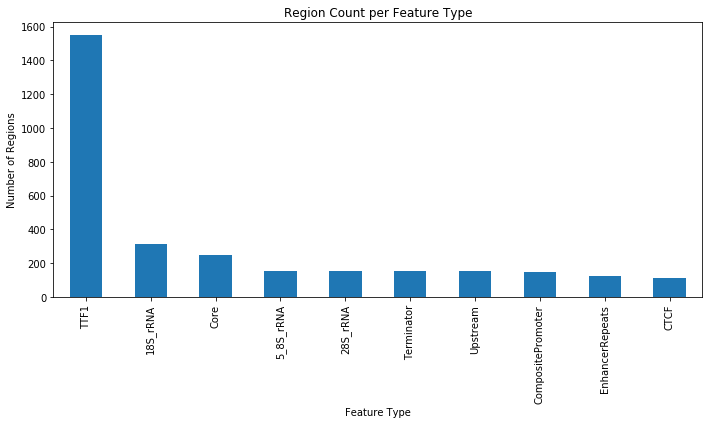

In [11]:
counts = (
    df.groupby("feature_type")
      .size()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

counts.plot(kind="bar")

plt.title("Region Count per Feature Type")
plt.ylabel("Number of Regions")
plt.xlabel("Feature Type")

plt.tight_layout()

plt.savefig(
    "feature_type_region_count_evo2.png",
    dpi=300
)

plt.show()


In [12]:
summary = (
    df.groupby("feature_type")
      .agg(
          accuracy=("accuracy","mean"),
          bases=("evaluated_base_count","sum")
      )
      .sort_values("accuracy", ascending=False)
)

summary

,accuracy,bases
feature_type,,
18S_rRNA,0.479146,18662.0
28S_rRNA,0.429677,24174.0
Terminator,0.421622,4298.0
5_8S_rRNA,0.386519,771.0
Upstream,0.382211,468.0
EnhancerRepeats,0.375429,8000.0
CompositePromoter,0.357053,6855.0
TTF1,0.355072,1242.0
CTCF,0.350000,100.0


<Figure size 864x432 with 0 Axes>

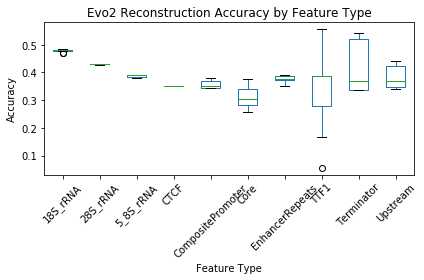

In [13]:
order = (
    df.groupby("feature_type")["accuracy"]
      .median()
      .sort_values(ascending=False)
      .index
)

plt.figure(figsize=(12,6))

df.boxplot(
    column="accuracy",
    by="feature_type",
    rot=45,
    grid=False
)

plt.title("Evo2 Reconstruction Accuracy by Feature Type")
plt.suptitle("")
plt.xlabel("Feature Type")
plt.ylabel("Accuracy")

plt.tight_layout()

plt.savefig(
    "accuracy_boxplot_evo2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

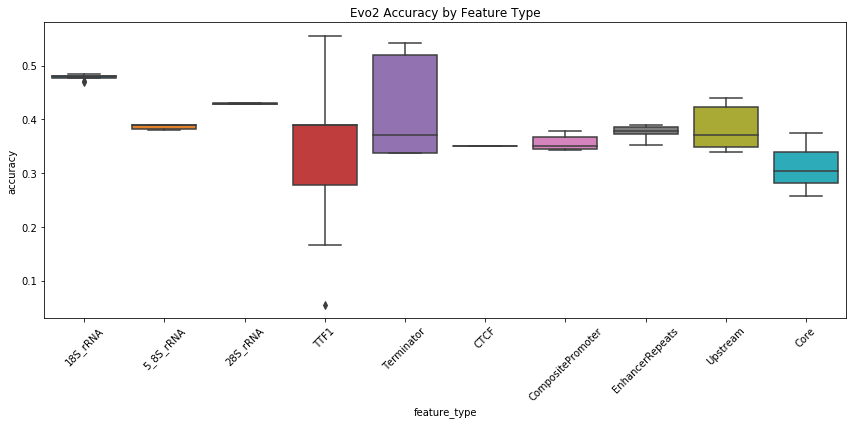

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="feature_type",
    y="accuracy"
)

plt.xticks(rotation=45)
plt.title("Evo2 Accuracy by Feature Type")

plt.tight_layout()
plt.show()

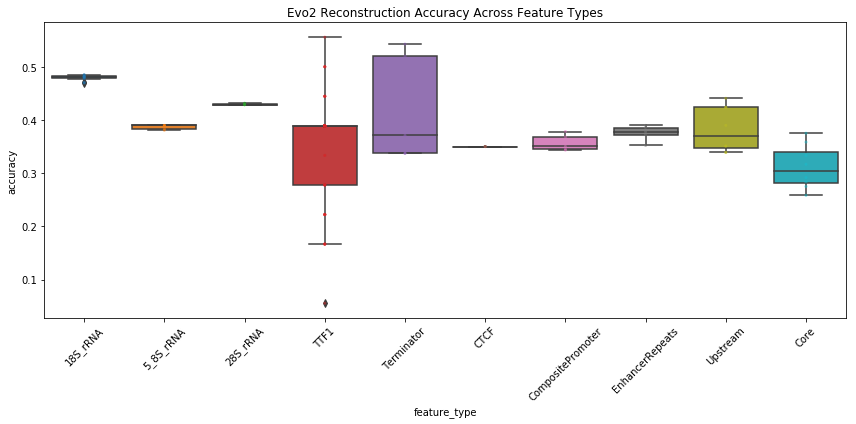

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="feature_type",
    y="accuracy"
)

sns.stripplot(
    data=df,
    x="feature_type",
    y="accuracy",
    alpha=0.5,
    size=3
)

plt.xticks(rotation=45)

plt.title(
    "Evo2 Reconstruction Accuracy Across Feature Types"
)

plt.tight_layout()

plt.show()